# Exploratory Data Analysis (EDA) on Diabetes Dataset

## Objective
The objective of this project is to analyze the Diabetes dataset to identify the major factors associated with diabetes, understand the distribution of patient characteristics, detect data quality issues, and generate meaningful insights before building machine learning models.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

df = pd.read_csv("diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dataset Overview

In [3]:
print("Shape:", df.shape)

Shape: (768, 9)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

## Data Cleaning

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
# Checking for impossible zero values

columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

(df[columns] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [10]:
# Replacing zero values with nan

cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df[cols] = df[cols].replace(0, np.nan)

In [11]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [12]:
# Fill missing values with median

for col in cols:
    df[col] = df[col].fillna(df[col].median())


In [13]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
df.drop_duplicates(inplace=True)

print(df.shape)

(768, 9)


In [16]:
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

## Statistical Summary


In [17]:
# Distribution Plots

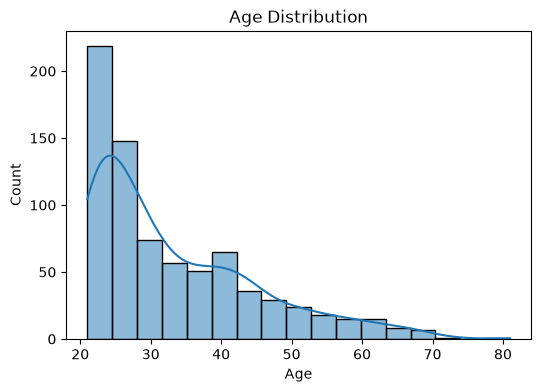

In [18]:

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

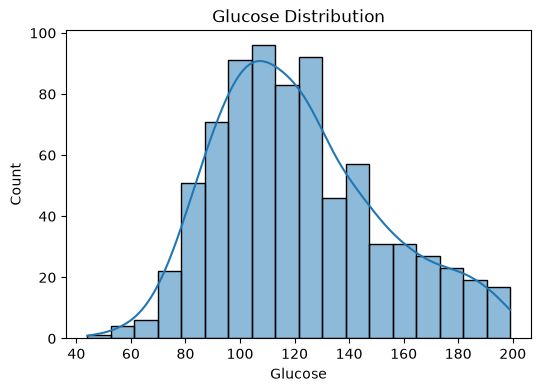

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df["Glucose"], kde=True)
plt.title("Glucose Distribution")
plt.show()

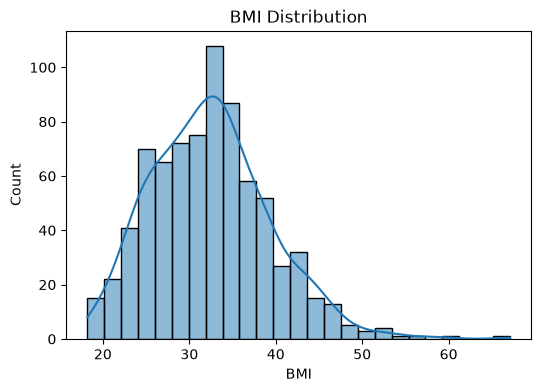

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution")
plt.show()

In [21]:
# Count Plots

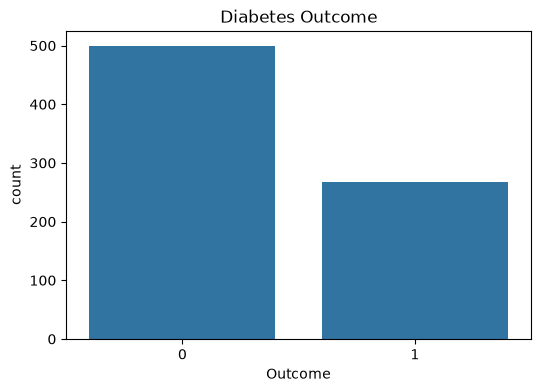

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome")
plt.show()

In [23]:
# Box Plots

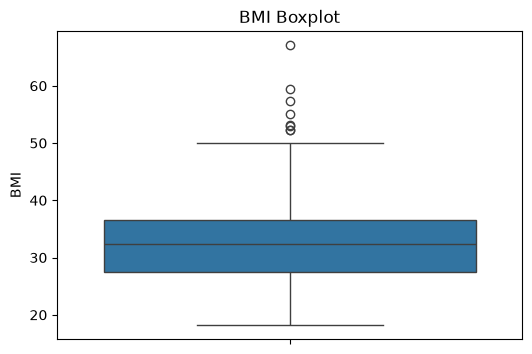

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["BMI"])
plt.title("BMI Boxplot")
plt.show()

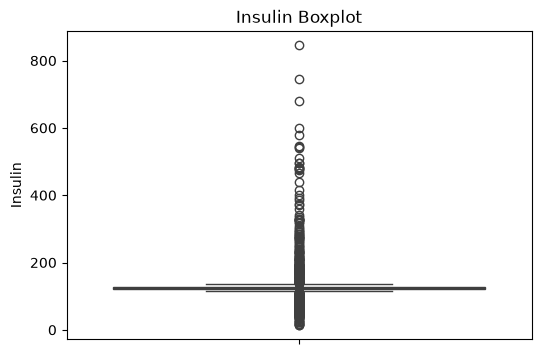

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Insulin"])
plt.title("Insulin Boxplot")
plt.show()

# Relationship Analysis

In [26]:
# Glucose v/s outcome

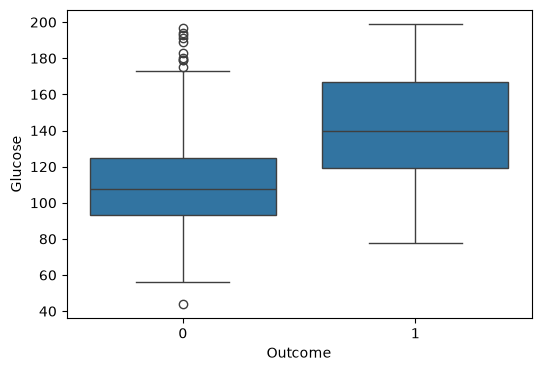

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()

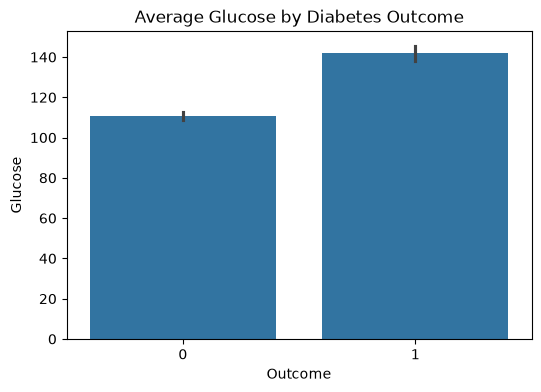

In [28]:
plt.figure(figsize=(6,4))

sns.barplot(x="Outcome", y="Glucose", data=df)

plt.title("Average Glucose by Diabetes Outcome")

plt.show()

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


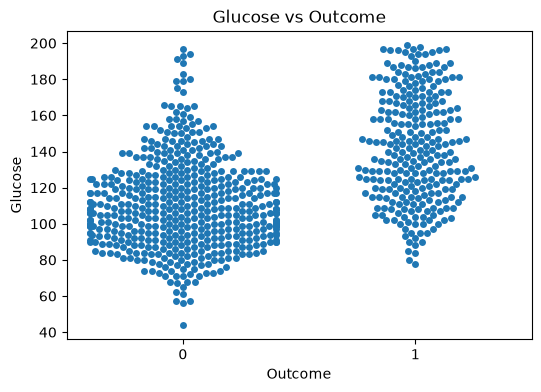

In [29]:
plt.figure(figsize=(6,4))

sns.swarmplot(x="Outcome", y="Glucose", data=df)

plt.title("Glucose vs Outcome")

plt.show()

In [30]:
# BMI vs Outcome

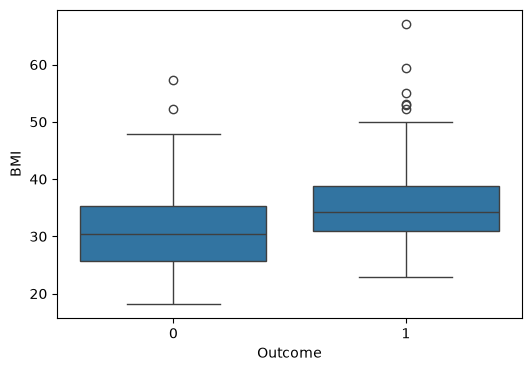

In [31]:

plt.figure(figsize=(6,4))

sns.boxplot(x="Outcome", y="BMI", data=df)

plt.show()

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


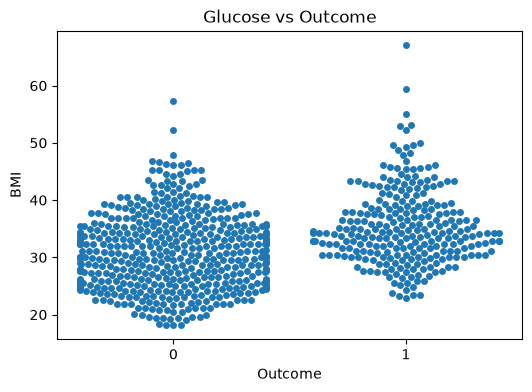

In [32]:
plt.figure(figsize=(6,4))
sns.swarmplot(x="Outcome", y="BMI", data=df)
plt.title("Glucose vs Outcome")
plt.show()

In [33]:
# Age vs Outcomes

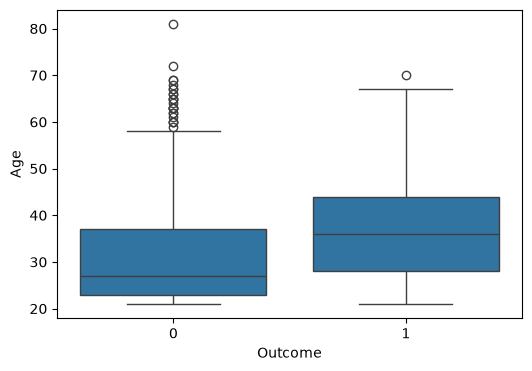

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Age", data=df)
plt.show()

In [35]:
# Pregnancy vs Outcomes

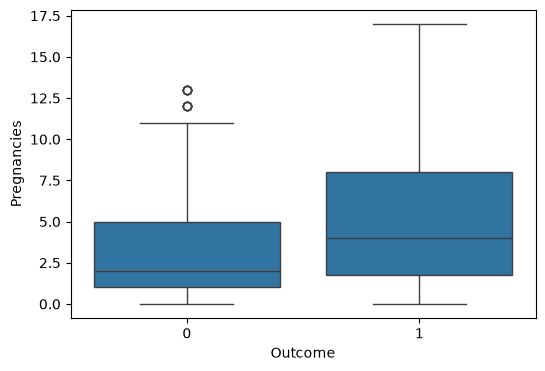

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Pregnancies", data=df)
plt.show()

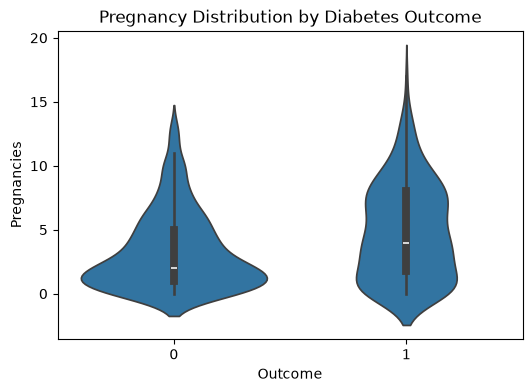

In [37]:
plt.figure(figsize=(6,4))

sns.violinplot(x="Outcome", y="Pregnancies", data=df)

plt.title("Pregnancy Distribution by Diabetes Outcome")

plt.show()

# Correlation Heatmap

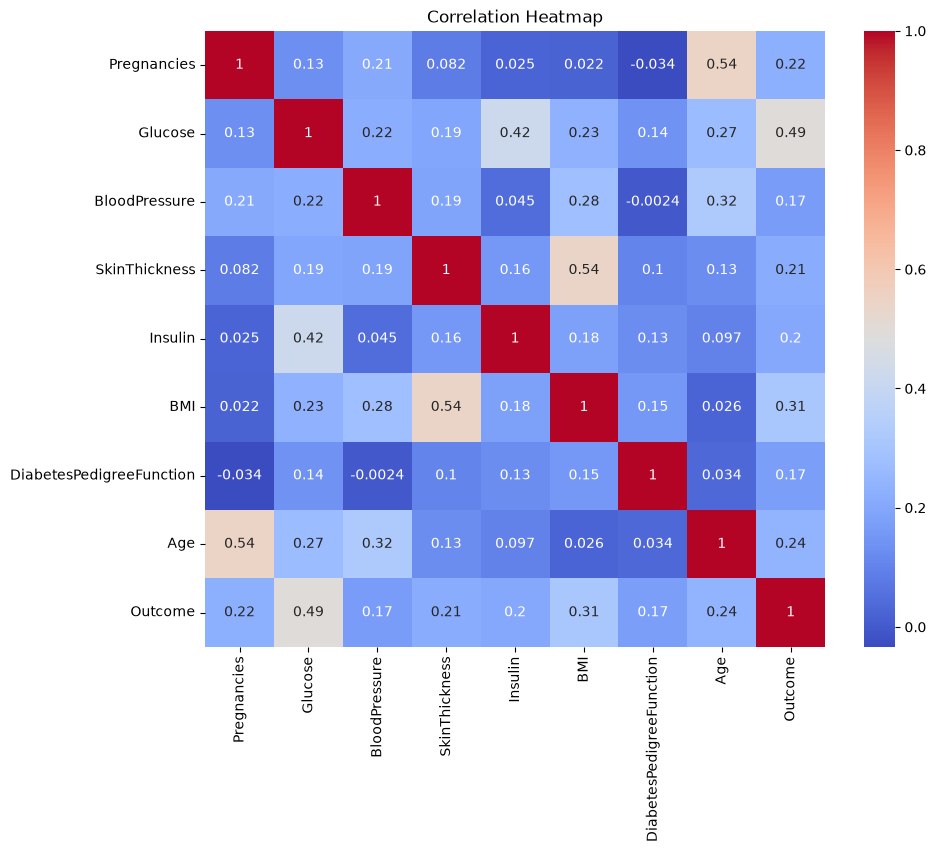

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Pair Plot

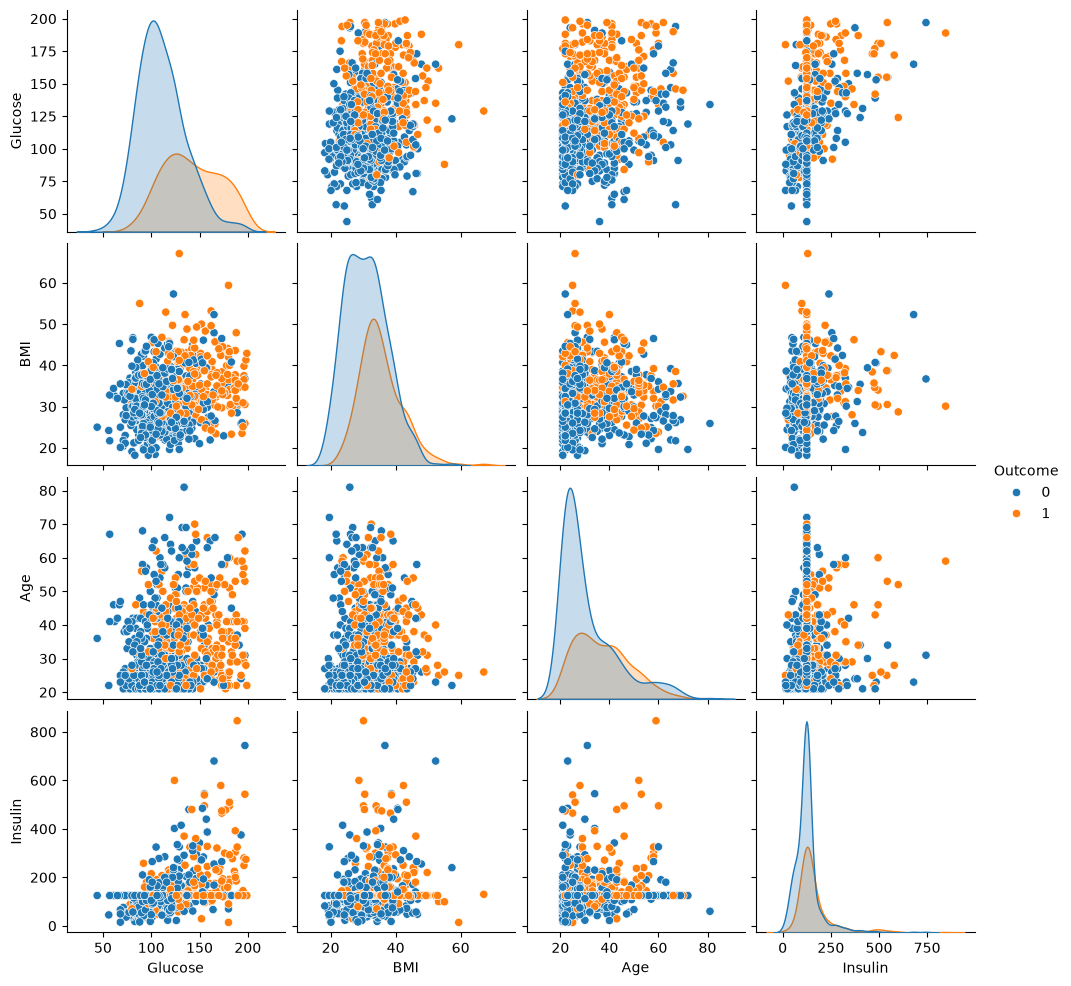

In [39]:
sns.pairplot(df,vars=["Glucose","BMI","Age","Insulin"],hue="Outcome")
plt.show()

# Trend Analysis

In [40]:
# Creating Age Groups

df["AgeGroup"] = pd.cut( df["Age"],bins=[20,30,40,50,60,80])

In [41]:
df["AgeGroup"]

0      (40, 50]
1      (30, 40]
2      (30, 40]
3      (20, 30]
4      (30, 40]
         ...   
763    (60, 80]
764    (20, 30]
765    (20, 30]
766    (40, 50]
767    (20, 30]
Name: AgeGroup, Length: 768, dtype: category
Categories (5, interval[int64, right]): [(20, 30] < (30, 40] < (40, 50] < (50, 60] < (60, 80]]

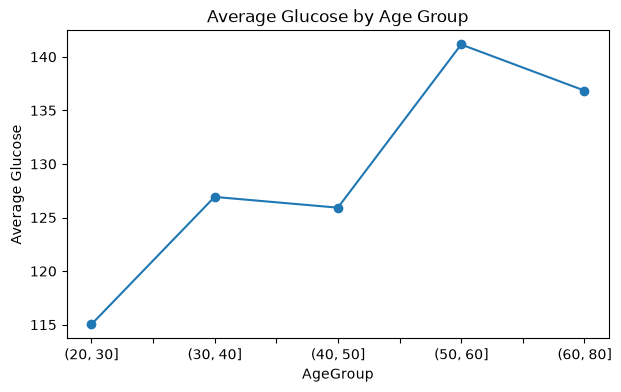

In [42]:
# Average Glucose b Age Groups

trend = df.groupby("AgeGroup")["Glucose"].mean()
trend.plot(marker="o", figsize=(7,4))
plt.ylabel("Average Glucose")
plt.title("Average Glucose by Age Group")
plt.show()

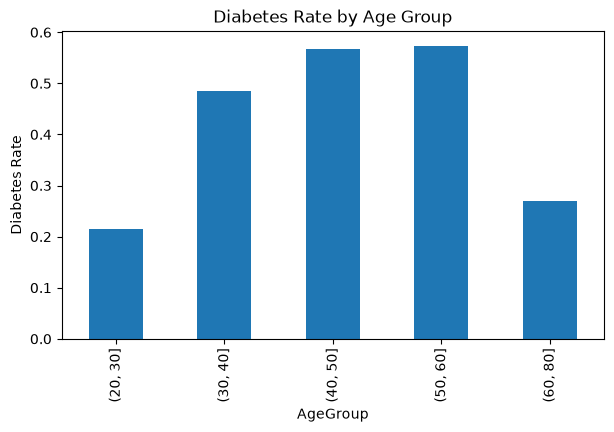

In [43]:
# Diabetes Outcome by age groups

rate = df.groupby("AgeGroup")["Outcome"].mean()
rate.plot(kind="bar", figsize=(7,4))
plt.ylabel("Diabetes Rate")
plt.title("Diabetes Rate by Age Group")
plt.show()

# Key Insights

1. Glucose has the strongest relationship with diabetes.
2. Higher BMI is associated with a higher likelihood of diabetes.
3. Diabetes prevalence increases with age.
4. Patients with more pregnancies tend to have higher diabetes rates.
5. Several medical variables contained impossible zero values and were treated as missing.
6. Insulin contains many outliers.
7. Most patients are non-diabetic.

# Recommendations

- Replace medically impossible zero values before modeling.
- Focus on Glucose, BMI, Age, and Pregnancies as important predictors.
- Handle outliers, especially in the Insulin feature.

In [44]:
# Save the preprocessed dataset
df.to_csv("diabetes_cleaned.csv", index=False)
print("Saved as diabetes_cleaned.csv")

Saved as diabetes_cleaned.csv
